# Cas A light echoes: the main results

A short guide to the five headline measurements and the code that produces
them. Read top to bottom; every cell runs in a few seconds.

### What we measured, in one paragraph

A light echo illuminates a thin sheet of interstellar dust, and that sheet
sweeps through the cloud as time passes. Each JWST epoch is therefore a *slice*
through the same 3D structure, at a slightly different depth. Stacking the
epochs gives a genuine three-dimensional map of the dust at ~10⁻³ pc
resolution. We divide the map into windows a few hundred pixels on a side,
measure the second-order structure function S₂ in each, and fit it with an
ellipsoid. The ellipsoid's axis ratios are the shape of the turbulence; its
orientation is how that shape sits relative to the echo plane.

### The five results

| | claim |
|---|---|
| 1 | The windows share one 3D shape: axes **1 : 0.29 : 0.17**, prolate at 6.9σ |
| 2 | They are not *identical* — the shapes differ by a measured **25–32 %** |
| 3 | The very different 2D appearances are explained by **slicing geometry alone** |
| 4 | One small-lag slope fits every window: **α ≈ 0.59** |
| 5 | The long axis prefers the **echo plane**, at every scale |

### What you need to run this

A clone of the repo and `numpy scipy pandas matplotlib`. Nothing here touches
the bulk input arrays (several GB, not in git), because the per-window fit
tables are tracked. The commands that *produce* those tables are in the last
section.

```bash
git clone <this repo> && cd casa
export PYTHONPATH="$PWD:$PWD/analysis"
```

If you want more depth than this notebook gives, the two companions are
`notebooks/topline_results.ipynb` (every claim in the report, with the
reasoning and the failed alternatives) and `notebooks/run_analysis.ipynb`
(the pipeline re-run from the images).

In [1]:
import os
import numpy as np
import pandas as pd

import make_tier_figures as mtf     # loads the fit tables, draws the figures
import shape_center as sc           # the shape-plane estimators

ROOT = os.path.dirname(os.path.dirname(os.path.abspath(mtf.__file__)))
os.chdir(ROOT)

K = 3                               # jackknife blocking; the report tabulates k=3
pd.set_option('display.width', 110)

## The table everything comes from

`mtf.load` returns one row per window: the fitted ellipsoid, its jackknife
uncertainties, and the window's SNR tier. Two filters matter and both are
applied everywhere below.

* `mtf.usable` drops windows whose fit did not converge to finite, positive
  axis ratios.
* `tier == 'q4'` keeps the top-SNR quartile. Every headline number is quoted
  from `q4`, because the lower tiers have error bars too large to constrain a
  shape — they appear in the figures, where the point is precisely to show the
  trend with SNR.

One column name is a trap worth learning now: on `mode == '3d'` rows, `b2b1` is
the in-plane slice ratio **predicted** by the 3D fit, not a measurement. The
measured value lives on the `mode == '2d'` rows. Result 3 uses both, and
confusing them turns a real test into a tautology.

In [2]:
d, _ = mtf.load(k=K)
d = d[mtf.usable(d)]
q4 = d[d.tier == 'q4']

# a2a1, a3a2: the axis ratios.  incl: angle between the long axis and W, the
# echo-plane normal.  alpha: log-log slope of S2 at small lag.
q4[['chunk', 'a2a1', 'se_a2a1', 'a3a2', 'se_a3a2', 'alpha', 'incl']].head(8)

,chunk,a2a1,se_a2a1,a3a2,se_a3a2,alpha,incl
0,r1600_c2000,0.286440,0.179340,0.467439,0.127895,0.644770,47.032113
1,r1600_c2400,0.418612,0.085959,0.594667,0.083579,0.561907,41.588991
2,r2000_c2400,0.188989,0.102261,0.665676,0.130143,0.537445,66.297892
3,r2000_c2800,0.272082,0.065918,0.731376,0.190450,0.619060,75.948920
4,r2000_c3200,0.203787,0.117945,0.923484,0.164918,0.590527,82.190428
5,r2000_c3600,0.217466,0.100215,0.424530,0.099879,0.560773,84.618282
6,r2400_c1200,0.343059,0.298912,0.434370,0.059661,0.549859,73.947769
7,r2400_c1600,0.490059,0.190510,0.319701,0.052929,0.655118,74.973296


## Result 1 — one shape, and it is prolate

`sc.ml_center_and_scatter` is the estimator used for every shape claim in the
paper. It takes the linear ratios and their standard errors and returns, **in
dex**, the maximum-likelihood common value together with the intrinsic scatter
around it. Fitting both at once is the point: a common value estimated while
pretending the scatter is zero is biased, and an intrinsic scatter estimated
against a non-maximising centre is inflated.

*Prolate* (cigar) versus *oblate* (pancake) is decided by
p = ln(a₁a₃/a₂²) — equivalently, whether a₃/a₂ exceeds a₂/a₁. Positive is
prolate.

In [3]:
rows = []
for c in ('a2a1', 'a3a2'):
    mu, sig, se_mu, _ = mtf.ml_center_and_scatter(q4[c].values, q4['se_' + c].values)
    rows.append(dict(ratio=c, common_value=10 ** mu, sigma_int_dex=sig, se_dex=se_mu))
shape = pd.DataFrame(rows).set_index('ratio')

# The headline axis ratios, 1 : a2/a1 : a3/a1.
r21, r32 = shape.common_value['a2a1'], shape.common_value['a3a2']
shape['axes_1_a2_a3'] = [r21, r21 * r32]
shape.round(4)

,common_value,sigma_int_dex,se_dex,axes_1_a2_a3
ratio,,,,
a2a1,0.2854,0.1203,0.0392,0.2854
a3a2,0.6008,0.0957,0.0247,0.1715


In [4]:
# Prolateness, in dex, propagating each window's errors into log space.
P = np.log10(q4.a3a2.values) - np.log10(q4.a2a1.values)
sP = np.hypot((q4.se_a2a1 / q4.a2a1 / np.log(10)).values,
              (q4.se_a3a2 / q4.a3a2 / np.log(10)).values)
muP, sigP = sc.ml_center_and_scatter(P, sP)
seP = 1 / np.sqrt((1 / (sP ** 2 + sigP ** 2)).sum())

pd.Series({'prolateness_dex': muP, 'se_dex': seP, 'significance_sigma': muP / seP,
           'n_prolate': (P > 0).sum(), 'n_windows': len(P)}).round(3)

prolateness_dex        0.350
se_dex                 0.051
significance_sigma     6.917
n_prolate             25.000
n_windows             29.000
dtype: float64

Axes **1 : 0.29 : 0.17**, prolate at **6.9σ**, with 25 of 29 windows
individually prolate. This is the paper's central shape measurement.

## Result 2 — the shapes are not identical, and we can say by how much

The honest version of result 1. `sc.profile_ci` profiles the likelihood over
the intrinsic scatter, giving both a 68 % interval and the Δχ² against
σ_int = 0 — i.e. against the hypothesis that all windows share one *exact*
shape.

That hypothesis is rejected for both ratios. The claim to make is therefore not
"the shapes are identical" but "the shapes differ by a measured 25–32 %, and
most of the apparent window-to-window spread is measurement noise."

In [5]:
from scipy import stats

rows = []
for c in ('a2a1', 'a3a2'):
    lv = np.log10(q4[c].values)
    sl = (q4['se_' + c] / q4[c] / np.log(10)).values
    sig, lo, hi, dchi2 = sc.profile_ci(lv, sl)
    rows.append(dict(ratio=c, sigma_int_dex=sig, ci68_lo=lo, ci68_hi=hi,
                     percent=100 * (10 ** sig - 1),
                     p_zero_scatter=stats.chi2.sf(dchi2, 1)))
scat = pd.DataFrame(rows).set_index('ratio')

# p is formatted rather than rounded: a3a2's value is 6e-6, which .round(4)
# would display as 0.0000 and throw away the whole point.
scat['p_zero_scatter'] = scat.p_zero_scatter.map('{:.1e}'.format)
scat.round(4)

,sigma_int_dex,ci68_lo,ci68_hi,percent,p_zero_scatter
ratio,,,,,
a2a1,0.1203,0.0844,0.1613,31.9189,6.0e-03
a3a2,0.0957,0.0759,0.1189,24.6395,6.4e-06


## Result 3 — the 2D appearance is slicing, not structure

This is the result the project exists to establish. In the plane of the echo
the windows look nothing like each other: the measured in-plane axis ratio runs
from 0.12 (a narrow filament) to 0.87 (nearly round). If the underlying 3D
shapes really are the same, that spread must be geometry — a fixed ellipsoid
cut at different angles gives different-looking cross-sections, round when
sliced across the long axis and elongated when sliced along it.

That predicts a specific correlation: windows whose long axis points along W
(small `incl`) should look round, and windows whose long axis lies in the plane
(large `incl`) should look elongated. Note this uses the **measured** 2D ratio
from the `mode == '2d'` rows, not the 3D fit's prediction.

In [6]:
tag = 'r%g_s%d_k%d' % (mtf.RCUT, mtf.STRIDE, K)
raw = pd.read_csv('results/singleband_powerlaw_%s.csv' % tag)
meas2d = raw[(raw['mode'] == '2d') & (raw.profile == 'powerlaw')]

j = q4[['row', 'col', 'incl']].merge(
    meas2d[['row', 'col', 'b2b1']], on=['row', 'col'])   # b2b1: measured, in-plane

rho, p = stats.spearmanr(j.incl, j.b2b1)

# p formatted, not rounded -- it is 3e-05.
pd.Series({'spearman_rho': round(rho, 4), 'p_value': '%.1e' % p,
           'n_windows': len(j), 'b2b1_min': round(j.b2b1.min(), 4),
           'b2b1_max': round(j.b2b1.max(), 4)})

spearman_rho    -0.6941
p_value         3.0e-05
n_windows            29
b2b1_min         0.1218
b2b1_max         0.8728
dtype: object

ρ = **−0.69** (p = 3 × 10⁻⁵). The sign is the one geometry predicts, and the
7.5× range in 2D appearance needs no 3D variation to explain it.

One limitation stated plainly, because a referee will raise it: this shows the
2D spread is *consistent with* pure slicing, not that 3D variation is absent.
The 2D data could only have detected 3D scatter above ≈0.27 dex, and result 2
measures 0.12 dex — a factor 2.3 below what 2D could ever have seen. The 3D
measurement is what settles it. `topline_results.ipynb` §1.6 has that
sensitivity curve.

## Result 4 — one small-lag slope for every window

α is the log-log slope of S₂ inside r < 0.1 ly. It is the same in every window,
which says the turbulence has a single scaling regime across the cloud even
where the shapes differ slightly.

α ≈ 0.59 sits below the Kolmogorov 2/3. That is expected rather than alarming:
this traces *density*, not velocity, so the comparison is not direct.

In [7]:
mu, sig, se_mu, _ = mtf.ml_center_and_scatter(q4.alpha.values, q4.se_alpha.values)

pd.Series({'median': np.median(q4.alpha), 'ml_common': 10 ** mu,
           'sigma_int_dex': sig, 'se_dex': se_mu,
           'min': q4.alpha.min(), 'max': q4.alpha.max(),
           'median_jackknife_se': np.median(q4.se_alpha)}).round(4)

median                 0.5905
ml_common              0.5821
sigma_int_dex          0.0366
se_dex                 0.0100
min                    0.4134
max                    0.7335
median_jackknife_se    0.0538
dtype: float64

## Result 5 — the long axis prefers the echo plane

`incl` is the unsigned angle between the fitted long axis and W, the normal to
the echo plane, folded to [0°, 90°]. 90° means the long axis lies in the plane;
0° means it points along W.

The comparison to make is against *isotropic* axes, not against 45°. Random
unsigned 3D directions have a median angle of 60°, because there is more solid
angle near the equator. The KS test below is against that isotropic
distribution, which is uniform in cos(angle).

In [8]:
v = q4.incl.dropna()
ks = stats.kstest(np.cos(np.radians(v)), 'uniform')     # isotropic null

pd.Series({'median_angle_deg': round(v.median(), 1),
           'isotropic_median_deg': 60.0,
           'frac_within_30deg_of_plane': round((v > 60).mean(), 3),
           'frac_within_30deg_of_W': round((v < 30).mean(), 3),
           'ks_p_vs_isotropic': '%.1e' % ks.pvalue, 'n_windows': len(v)})

median_angle_deg                 73.6
isotropic_median_deg             60.0
frac_within_30deg_of_plane      0.828
frac_within_30deg_of_W            0.0
ks_p_vs_isotropic             3.2e-04
n_windows                          29
dtype: object

Median **74°** against an isotropic 60°, with 83 % of windows within 30° of the
plane and none within 30° of W.

Two things make this more than a fitting artifact, both worked through in
`topline_results.ipynb`. First, splitting each window's lags in two and
refitting independently recovers the same long axis to 7°, so the orientation
is scale-invariant rather than set by one lag range. Second, and more
convincing, the orientation is confirmed *without using the ellipsoid fit at
all*: the gradient structure tensor of the raw first-epoch image measures how
striated each window looks, and that tracks the fitted angle at ρ = +0.65.
A fit inventing orientations could not predict the appearance of the images.

W is sampled ~14× more coarsely than the in-plane axes, which raises the
obvious worry that this preference is a sampling artifact. It is not, and the
worry has its sign backwards: an injection test shows coarse W sampling
*lengthens* the recovered ellipsoid along W, rotating the long axis toward W
and away from the plane. The measured angle is a conservative floor.

## The two published figures

`mtf.main` regenerates both. These run at **k = 4**, not k = 3, and the reason
is worth knowing: the `k=3` table holds only the 29 top-SNR windows, while
`k=4` covers all 115. A three-tier figure needs all of them — drawn at `k=3` it
would render one tier and silently drop the other two. The headline numbers
above are unaffected because they are all quoted from `q4` anyway; the small
shift in common shape between blockings (0.285 vs 0.281) is the documented
blocking systematic.

The figures also apply a display clip that drops collapsed fits with ratios
~10⁻¹⁶. That affects only what is drawn — the fits always use the full usable
sample, so no printed number moves if the threshold changes.

In [9]:
import matplotlib
matplotlib.use('Agg')

# Relative path, and the return value assigned rather than echoed: main() both
# prints and returns absolute paths, which would bake this machine's directory
# layout into the committed notebook.  We chdir'd to ROOT in the setup cell.
# n_drawn should be 100 of 115.
out = os.path.join('notebooks', 'figures')
written = mtf.main(k=4, outdir=out)

k=4  n_drawn=100  range=[0.080, 1.143]
common shape  a2/a1=0.2811  a3/a2=0.5958
intrinsic sig 0.127, 0.100 dex | median meas SE 0.248, 0.073 dex
wrote notebooks/figures/b2b1_vs_inclination_all115.png
      notebooks/figures/shape_plane_all115.png


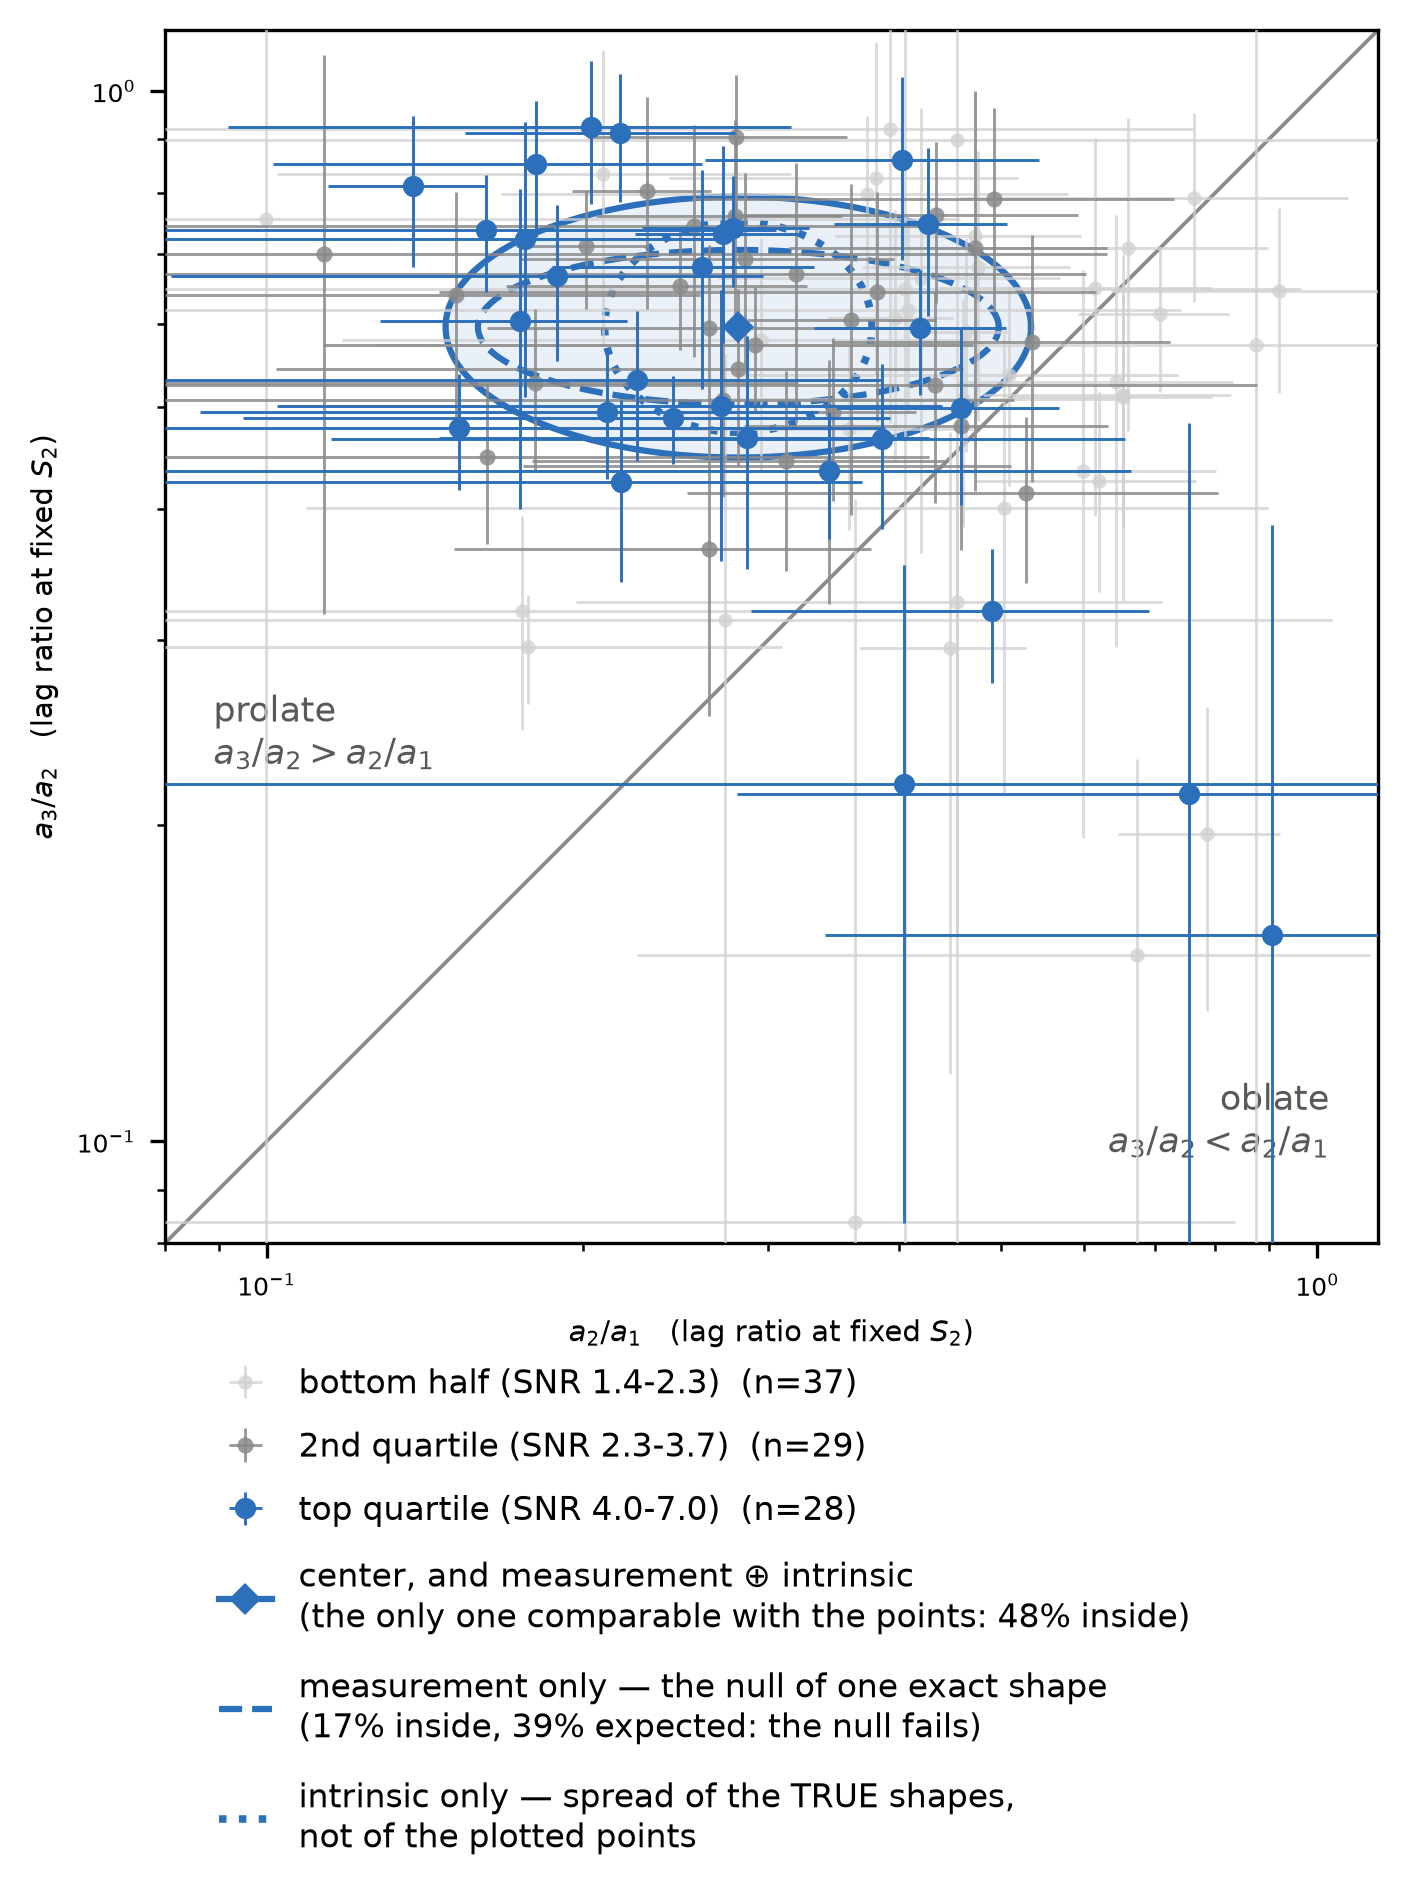

In [10]:
from IPython.display import Image, display

# Left: every window in the shape plane, by SNR tier -- the high-SNR windows
# cluster, the low-SNR ones scatter with their error bars.
display(Image(filename=os.path.join(out, 'shape_plane_all115.png'), width=640))

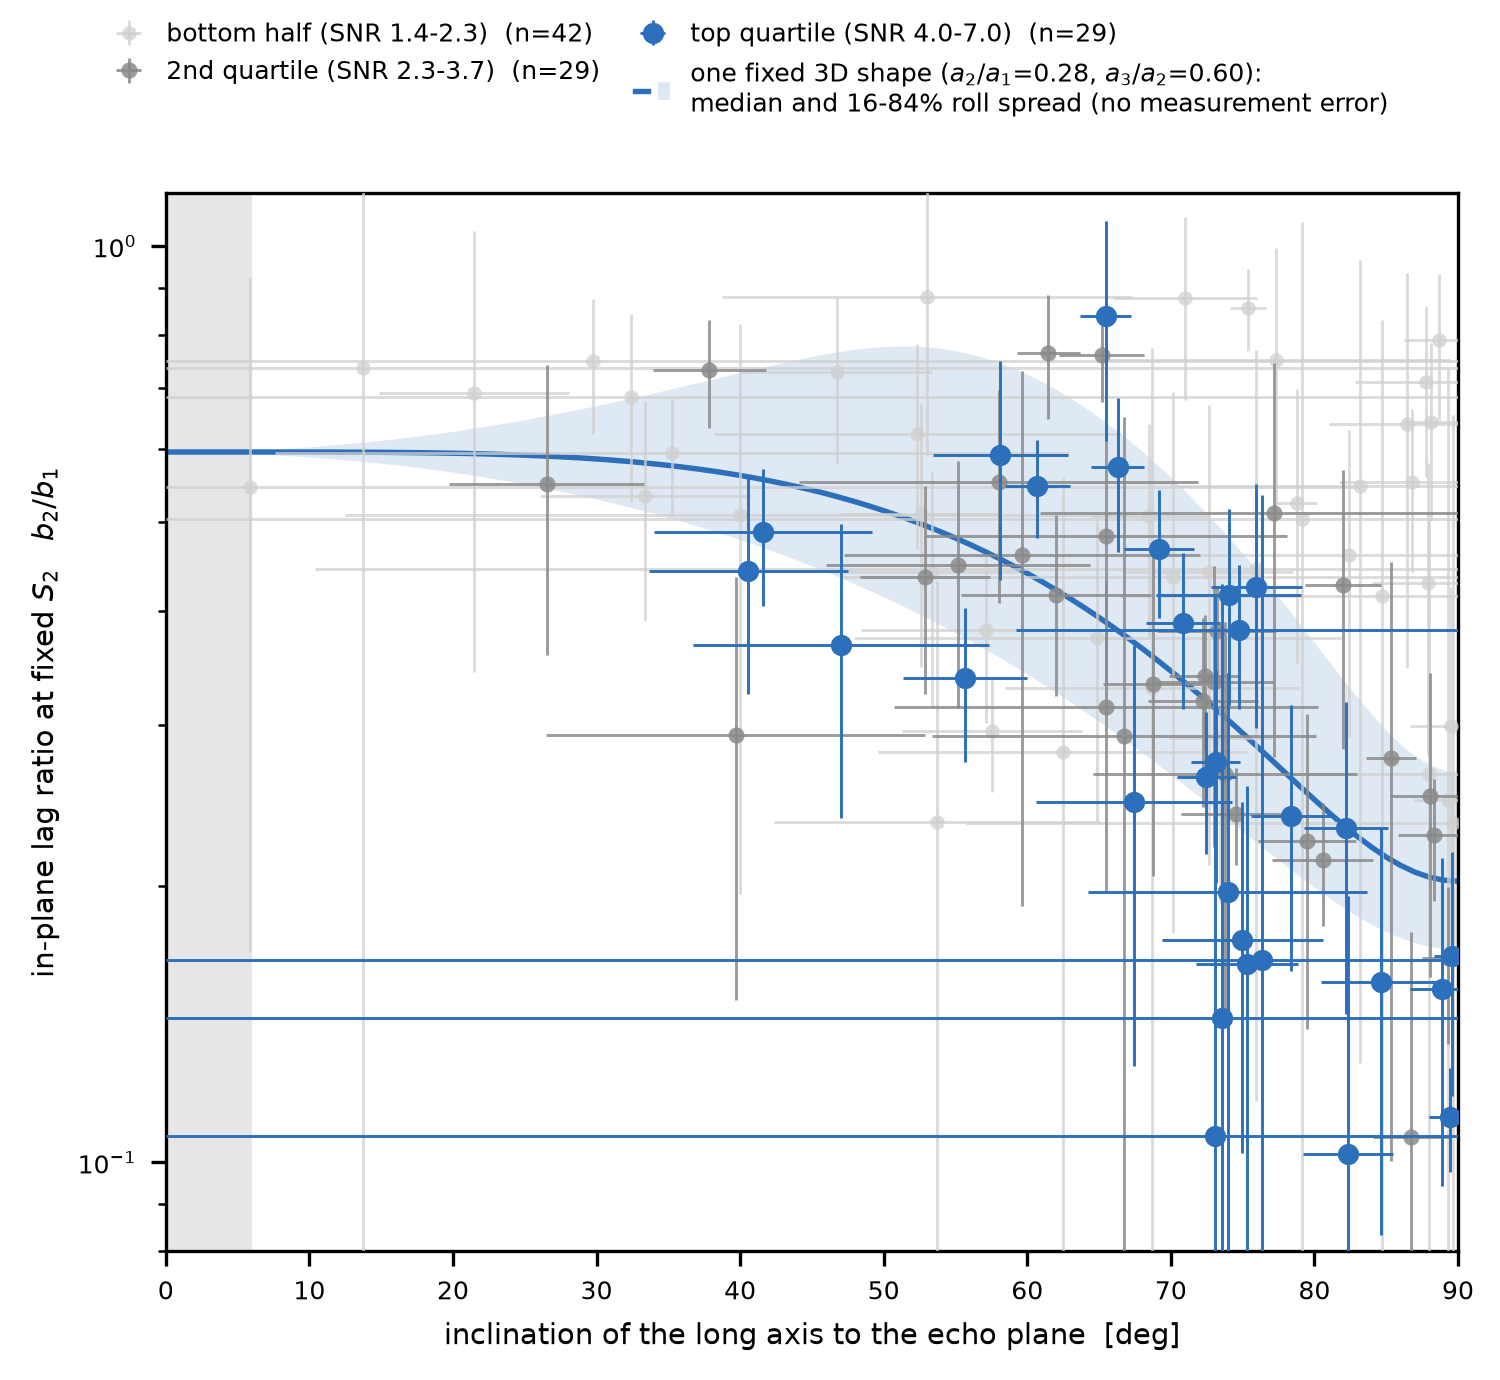

In [11]:
# Result 3 as a figure: measured 2D ratio against the long axis's angle to W,
# with the slicing model's prediction overlaid.
display(Image(filename=os.path.join(out, 'b2b1_vs_inclination_all115.png'), width=640))

## Re-running the fits from the images

Everything above ran from tracked tables. Producing those tables needs the bulk
arrays (`resampled_epochs_noclip.npy` and friends, symlinked into `data/` — see
`README_FORK.md`) and hours of compute, so it is out of scope here. The
commands, in order:

```bash
python analysis/noise_audit.py                 # SNR tiers -- must run first
python analysis/singleband_powerlaw.py --k 4   # the deliverable fit table
python analysis/scale_profile.py               # shape vs lag scale
python analysis/scale_profile_2d.py            # its in-plane twin
python analysis/summarize_scale_profile.py     # -> *_bands.csv, *_slopes.csv
python analysis/summarize_scale_slopes.py      # -> *_slopes_summary.csv
```

`notebooks/run_analysis.ipynb` does this as a guided run instead, gated by a
`RUN_LEVEL` knob (≈4 min for one window in detail, ≈30 min for the figures,
≈60 min for everything) and diffing every table it computes against the tracked
one. It writes under `rerun/`, so the published tables are never touched.

Both notebooks in this repo are generated from builder scripts and committed
with their outputs. Do not hand-edit the `.ipynb` — edit the builder and
regenerate:

```bash
python analysis/build_main_results_notebook.py
python analysis/execute_notebook_inproc.py notebooks/main_results.ipynb
```